# Ejercicio 2. Clasificación de prendas de vestir con Fashion MNIST y TensorFlow

Curso de Inteligencia Artificial y Minirobots. Capítulo 5, Introducción a las Redes Neuronales Artificiales (José J. Martínez P.)

Ejercicio 5.9, numeral 2: *Con base en la librería tensorflow, descargue el data set fashion MNIST. Haga una clasificación de prendas de vestir. Explique cada una de las funciones y las principales instrucciones, saque conclusiones.*

---

## 1. Planteamiento

Fashion MNIST fue publicado por Zalando Research como reemplazo directo del MNIST de dígitos descrito en la sección 5.4 del capítulo. Conserva exactamente el mismo formato: imágenes en escala de grises de 28 × 28 = 784 píxeles, 60 000 ejemplos de entrenamiento, 10 000 de prueba y 10 clases. La diferencia está en el contenido: en lugar de dígitos, cada imagen es una prenda o un accesorio. Se considera un problema más difícil que MNIST porque varias clases se parecen mucho entre sí (camiseta, camisa, buzo y abrigo), mientras que los dígitos manuscritos se distinguen con más facilidad.

En términos de la notación del capítulo, cada par de entrenamiento $(X^{(i)}, Y^{(i)})$ tiene un vector de características $X^{(i)}$ de 784 valores y un rótulo $Y^{(i)}\in\{0,\dots,9\}$; se trata de un problema de **multi-clasificación** con $k = 10$ clases.

El notebook entrena tres modelos de complejidad creciente, explica cada instrucción, verifica a mano la propagación que realiza TensorFlow y analiza los errores del mejor modelo.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"        # oculta los mensajes informativos de TensorFlow
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Version de TensorFlow:", tf.__version__)
tf.keras.utils.set_random_seed(2026)            # fija las semillas de Python, NumPy y TensorFlow
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

Version de TensorFlow: 2.21.0


**Instrucciones de esta celda.**

- `import tensorflow as tf` carga TensorFlow, que incluye **Keras** (`tf.keras`), la interfaz de alto nivel con la que se definen y entrenan las redes.
- `tf.keras.utils.set_random_seed(2026)` fija la semilla de los generadores aleatorios de Python, NumPy y TensorFlow. La inicialización de los pesos y el orden en que se presentan los ejemplos dependen de ella, así que fijarla hace el experimento repetible. En una GPU de Colab pueden aparecer diferencias de unas décimas de punto porcentual, porque algunas operaciones paralelas no son deterministas.

## 2. Carga del conjunto de datos

In [2]:
fashion = tf.keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fashion.load_data()

nombres = ["Camiseta/top", "Pantalon", "Buzo", "Vestido", "Abrigo",
           "Sandalia", "Camisa", "Tenis", "Bolso", "Botin"]

print("Entrenamiento:", x_train_full.shape, x_train_full.dtype, "  rotulos:", y_train_full.shape)
print("Prueba:       ", x_test.shape, x_test.dtype, "  rotulos:", y_test.shape)
print("Rango de los pixeles:", x_train_full.min(), "a", x_train_full.max())
print("\nEjemplos por clase en entrenamiento:")
for c, n in enumerate(np.bincount(y_train_full)):
    print(f"   {c}  {nombres[c]:<14}{n:>6}")

Entrenamiento: (60000, 28, 28) uint8   rotulos: (60000,)
Prueba:        (10000, 28, 28) uint8   rotulos: (10000,)
Rango de los pixeles: 0 a 255

Ejemplos por clase en entrenamiento:
   0  Camiseta/top    6000
   1  Pantalon        6000
   2  Buzo            6000
   3  Vestido         6000
   4  Abrigo          6000
   5  Sandalia        6000
   6  Camisa          6000
   7  Tenis           6000
   8  Bolso           6000
   9  Botin           6000


**Instrucciones de esta celda.**

- `tf.keras.datasets.fashion_mnist.load_data()` descarga los cuatro archivos del conjunto (unos 30 MB) la primera vez y los guarda en `~/.keras/datasets`; las siguientes veces los lee de allí. Devuelve dos tuplas: `(x_train, y_train)` y `(x_test, y_test)`.
- Las imágenes llegan como un arreglo de NumPy de tipo `uint8` con forma `(n, 28, 28)`, es decir, valores enteros de 0 (negro) a 255 (blanco).
- Los rótulos son enteros de 0 a 9. El conjunto no trae los nombres de las clases, por eso se definen en la lista `nombres`.

Las diez clases tienen exactamente 6 000 ejemplos cada una. Un conjunto balanceado permite usar la exactitud (*accuracy*) como métrica principal sin que una clase mayoritaria la distorsione.

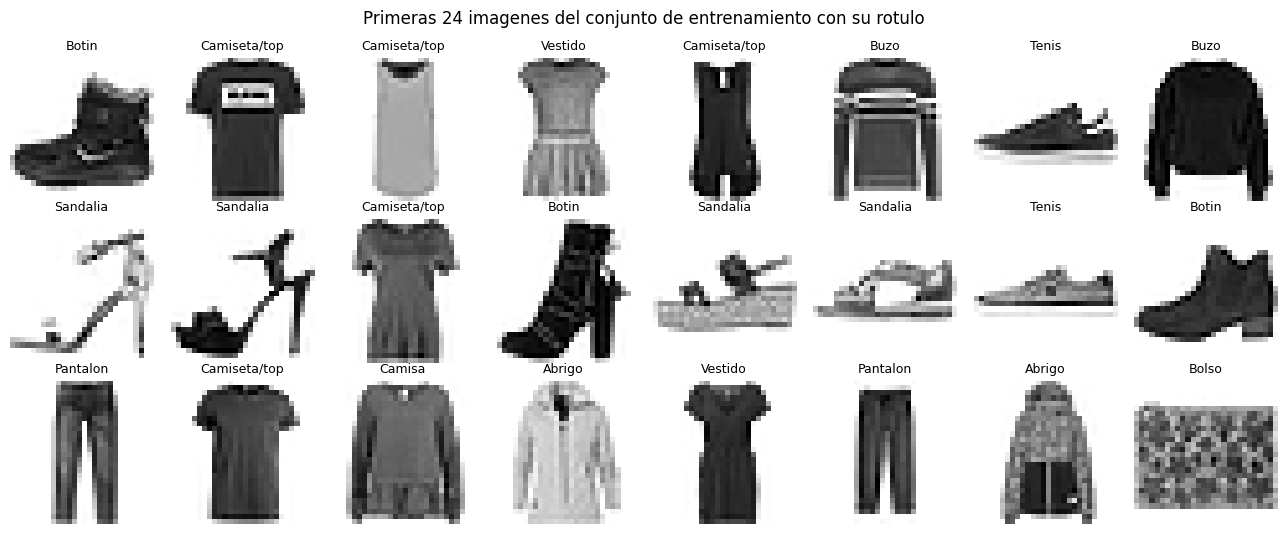

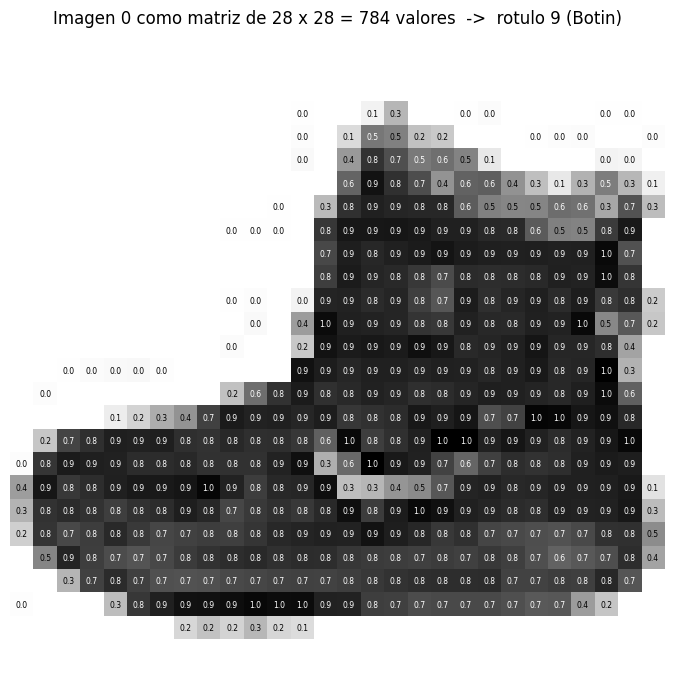

In [3]:
fig, ax = plt.subplots(3, 8, figsize=(13, 5.4))
for i, a in enumerate(ax.ravel()):
    a.imshow(x_train_full[i], cmap="gray_r")
    a.set_title(nombres[y_train_full[i]], fontsize=9)
    a.axis("off")
plt.suptitle("Primeras 24 imagenes del conjunto de entrenamiento con su rotulo")
plt.tight_layout(); plt.show()

# Equivalente a la figura 5.14 del capitulo: la imagen es solo una matriz de numeros
fig, ax = plt.subplots(figsize=(8.5, 8.5))
img = x_train_full[0]
ax.imshow(img, cmap="gray_r")
for (r, c), v in np.ndenumerate(img):
    if v > 0:
        ax.text(c, r, f"{v/255:.1f}", ha="center", va="center", fontsize=5.5,
                color="white" if v > 128 else "black")
ax.set_title(f"Imagen 0 como matriz de 28 x 28 = 784 valores  ->  rotulo {y_train_full[0]} ({nombres[y_train_full[0]]})")
ax.axis("off"); plt.show()

La segunda figura corresponde a la figura 5.14 del capítulo: para la red, una prenda no es más que una matriz de 784 intensidades (aquí ya escaladas a $[0,1]$) acompañada de su rótulo.

## 3. Preprocesamiento y división del conjunto

In [4]:
x_train_full = x_train_full.astype("float32") / 255.0
x_test       = x_test.astype("float32") / 255.0

x_train, y_train = x_train_full[:50_000], y_train_full[:50_000]
x_val,   y_val   = x_train_full[50_000:], y_train_full[50_000:]

print("Entrenamiento:", x_train.shape[0], " Validacion:", x_val.shape[0], " Prueba:", x_test.shape[0])
print("Clases en validacion:", np.bincount(y_val))

Entrenamiento: 50000  Validacion: 10000  Prueba: 10000
Clases en validacion: [1023  988 1008 1021 1050  996  970  955  968 1021]


**Normalización.** Dividir por 255 lleva los píxeles de $[0, 255]$ a $[0, 1]$. Sin este paso, los valores de $Z = W^TX + B$ en la primera capa serían cientos de veces mayores, las activaciones se saturarían y los gradientes serían muy desiguales entre parámetros; el entrenamiento sería más lento e inestable. Se convierte además a `float32`, el tipo con el que trabaja TensorFlow.

**División en tres conjuntos.** Siguiendo la sección 5.4 del capítulo:

| Conjunto | Ejemplos | Uso |
|---|:-:|---|
| Entrenamiento | 50 000 | ajustar los pesos con retropropagación |
| Validación | 10 000 | vigilar el sobreentrenamiento y elegir cuándo parar |
| Prueba | 10 000 | estimar el desempeño en el mundo real; se usa **una sola vez**, al final |

La validación se toma de los últimos 10 000 ejemplos de entrenamiento y, como muestra la salida, también queda aproximadamente balanceada.

## 4. Modelo de referencia: una capa sin neuronas ocultas

Para saber cuánto aportan las capas ocultas, se entrena primero la red más simple posible: las 784 entradas conectadas directamente a 10 neuronas de salida. Es el equivalente de las compuertas de una sola neurona de la sección 5.3, pero con diez salidas; en estadística se conoce como regresión logística multinomial.

In [5]:
modelo_ref = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation="softmax")
], name="referencia_sin_capas_ocultas")

modelo_ref.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_ref = modelo_ref.fit(x_train, y_train, epochs=10, batch_size=32,
                          validation_data=(x_val, y_val), verbose=2)

Epoch 1/10


1563/1563 - 3s - 2ms/step - accuracy: 0.7888 - loss: 0.6194 - val_accuracy: 0.8199 - val_loss: 0.5111


Epoch 2/10


1563/1563 - 3s - 2ms/step - accuracy: 0.8401 - loss: 0.4698 - val_accuracy: 0.8340 - val_loss: 0.4730


Epoch 3/10


...

1563/1563 - 3s - 2ms/step - accuracy: 0.8624 - loss: 0.4001 - val_accuracy: 0.8496 - val_loss: 0.4324


Epoch 9/10


1563/1563 - 3s - 2ms/step - accuracy: 0.8636 - loss: 0.3964 - val_accuracy: 0.8504 - val_loss: 0.4309


Epoch 10/10


1563/1563 - 3s - 2ms/step - accuracy: 0.8641 - loss: 0.3932 - val_accuracy: 0.8512 - val_loss: 0.4298


## 5. Red neuronal con una capa oculta

### 5.1 Definición de la arquitectura

In [6]:
tf.keras.utils.set_random_seed(2026)
modelo = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),                    # capa 0: la imagen
    tf.keras.layers.Flatten(),                         # 28x28 -> vector de 784
    tf.keras.layers.Dense(128, activation="relu"),     # capa oculta
    tf.keras.layers.Dense(10, activation="softmax")    # capa de salida: una neurona por clase
], name="mlp_128")
modelo.summary()

Model: "mlp_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

**Instrucciones de esta celda.**

- `tf.keras.Sequential([...])` crea una red *feedforward* en la que cada capa recibe la salida de la anterior, exactamente como la red de la figura 5.13 del capítulo.
- `tf.keras.Input(shape=(28, 28))` declara la forma de cada ejemplo de entrada. No tiene pesos.
- `Flatten()` reorganiza la matriz de 28 × 28 en un vector de 784 componentes, que es el vector $X$ del capítulo. Tampoco tiene pesos.
- `Dense(128, activation="relu")` es una capa **completamente conectada**: calcula $Z^{(1)} = W^{(1)T}X + B^{(1)}$ y aplica la función ReLU, $g(z)=\max(0,z)$, de la figura 5.7. Se prefiere a la sigmoide porque no se satura para valores positivos, lo que acelera el entrenamiento, como indica el capítulo para redes profundas.
- `Dense(10, activation="softmax")` es la capa de salida. La función **softmax** convierte los diez valores $z_j$ en probabilidades que suman 1:
$$\text{softmax}(z)_j = \frac{e^{z_j}}{\sum_{i=1}^{10} e^{z_i}}$$
La clase predicha es la de mayor probabilidad. Softmax cumple aquí el papel que la sigmoide cumplía en las compuertas: cuando hay varias clases excluyentes, las salidas deben competir entre sí.

**Verificación del número de parámetros.** La capa oculta tiene una matriz $784\times128$ más 128 sesgos: $784\cdot128+128 = 100\,480$. La de salida, $128\cdot10+10 = 1\,290$. En total $101\,770$, que es lo que reporta `summary()`.

### 5.2 Compilación

In [7]:
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

`compile` asocia al modelo las tres piezas del algoritmo de aprendizaje de la sección 5.5:

- **Optimizador `Adam`**. Es una variante del descenso del gradiente $W \leftarrow W - \eta\,\partial E/\partial W$. Mantiene un promedio móvil del gradiente (inercia) y de su cuadrado, y con ellos adapta la tasa de aprendizaje de cada peso. `learning_rate=0.001` es la $\eta$ del capítulo. Los gradientes los calcula TensorFlow por retropropagación, de forma automática.
- **Función de pérdida `SparseCategoricalCrossentropy`**. El capítulo usa el error cuadrático $E=\tfrac12 e^Te$. Para clasificación con softmax se usa la entropía cruzada, $E = -\ln p_{y}$, donde $p_y$ es la probabilidad que la red asigna a la clase correcta. Penaliza fuertemente las respuestas seguras y equivocadas y, combinada con softmax, produce el gradiente sencillo $\partial E/\partial z_j = p_j - [j=y]$, que evita la saturación. El prefijo *Sparse* indica que los rótulos se entregan como enteros (3) y no como vectores *one-hot* (`[0,0,0,1,0,...]`).
- **Métrica `accuracy`**. Fracción de ejemplos cuya clase de mayor probabilidad coincide con el rótulo. Solo se reporta; no interviene en el ajuste de los pesos.

### 5.3 Entrenamiento

In [8]:
hist = modelo.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=2
)

Epoch 1/30


1563/1563 - 5s - 3ms/step - accuracy: 0.8185 - loss: 0.5165 - val_accuracy: 0.8268 - val_loss: 0.4670


Epoch 2/30


1563/1563 - 4s - 3ms/step - accuracy: 0.8609 - loss: 0.3880 - val_accuracy: 0.8490 - val_loss: 0.4068


Epoch 3/30


...

1563/1563 - 4s - 2ms/step - accuracy: 0.9516 - loss: 0.1359 - val_accuracy: 0.8776 - val_loss: 0.4837


Epoch 29/30


1563/1563 - 5s - 3ms/step - accuracy: 0.9535 - loss: 0.1304 - val_accuracy: 0.8736 - val_loss: 0.5069


Epoch 30/30


1563/1563 - 4s - 3ms/step - accuracy: 0.9545 - loss: 0.1275 - val_accuracy: 0.8696 - val_loss: 0.5232


**`fit`** ejecuta el ciclo de entrenamiento. En cada **época** recorre los 50 000 ejemplos en **lotes** (*batches*) de 32: para cada lote propaga, calcula la pérdida, retropropaga y actualiza los pesos, es decir, 1 563 actualizaciones por época. Al terminar cada época evalúa el modelo sobre el conjunto de validación, que nunca se usa para ajustar pesos. Devuelve un objeto `History` cuyo atributo `history` guarda la pérdida y la exactitud de cada época.

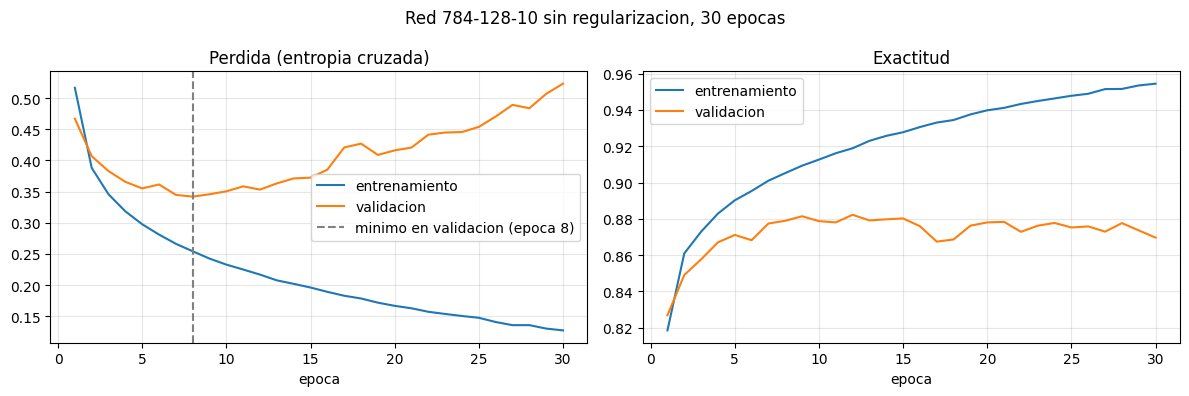

Epoca con menor perdida de validacion: 8
Al final: exactitud entrenamiento = 0.9545, validacion = 0.8696


In [9]:
def curvas(h, titulo):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ep = np.arange(1, len(h.history["loss"]) + 1)
    ax[0].plot(ep, h.history["loss"], label="entrenamiento")
    ax[0].plot(ep, h.history["val_loss"], label="validacion")
    mejor = int(np.argmin(h.history["val_loss"])) + 1
    ax[0].axvline(mejor, color="gray", ls="--", label=f"minimo en validacion (epoca {mejor})")
    ax[0].set_title("Perdida (entropia cruzada)"); ax[0].set_xlabel("epoca"); ax[0].legend()
    ax[1].plot(ep, h.history["accuracy"], label="entrenamiento")
    ax[1].plot(ep, h.history["val_accuracy"], label="validacion")
    ax[1].set_title("Exactitud"); ax[1].set_xlabel("epoca"); ax[1].legend()
    plt.suptitle(titulo); plt.tight_layout(); plt.show()
    return mejor

mejor = curvas(hist, "Red 784-128-10 sin regularizacion, 30 epocas")
print(f"Epoca con menor perdida de validacion: {mejor}")
print(f"Al final: exactitud entrenamiento = {hist.history['accuracy'][-1]:.4f}, "
      f"validacion = {hist.history['val_accuracy'][-1]:.4f}")

Las curvas reproducen el comportamiento de la figura 5.17 del capítulo. La pérdida de entrenamiento baja durante las 30 épocas, pero la de validación alcanza su mínimo hacia la época 8 y a partir de allí sube: al final la exactitud es de 95.5 % en entrenamiento y de solo 87.0 % en validación. La brecha creciente entre ambas es la señal de **sobreentrenamiento** (figura 5.12): la red empieza a memorizar particularidades del conjunto de entrenamiento que no se generalizan.

## 6. Red regularizada con *Dropout* y parada temprana

Se aplican dos técnicas estándar contra el sobreentrenamiento:

- **`Dropout(0.2)`**: durante el entrenamiento, en cada lote se "apaga" al azar el 20 % de las neuronas de la capa oculta (su salida se hace cero). Eso impide que la red dependa de combinaciones muy específicas de neuronas. Al predecir, todas las neuronas se usan.
- **`EarlyStopping`**: un *callback*, es decir, una función que Keras llama al final de cada época. Vigila la pérdida de validación y detiene el entrenamiento si no mejora durante `patience=5` épocas; con `restore_best_weights=True` deja los pesos de la mejor época. Automatiza la elección del punto de parada.

Epoch 1/40


1563/1563 - 5s - 3ms/step - accuracy: 0.8072 - loss: 0.5471 - val_accuracy: 0.8269 - val_loss: 0.4627


Epoch 2/40


1563/1563 - 5s - 3ms/step - accuracy: 0.8528 - loss: 0.4085 - val_accuracy: 0.8496 - val_loss: 0.4008


Epoch 3/40


...

1563/1563 - 4s - 3ms/step - accuracy: 0.9038 - loss: 0.2546 - val_accuracy: 0.8898 - val_loss: 0.3229


Epoch 16/40


1563/1563 - 4s - 3ms/step - accuracy: 0.9061 - loss: 0.2490 - val_accuracy: 0.8900 - val_loss: 0.3211


Epoch 17/40


1563/1563 - 4s - 3ms/step - accuracy: 0.9074 - loss: 0.2430 - val_accuracy: 0.8897 - val_loss: 0.3283


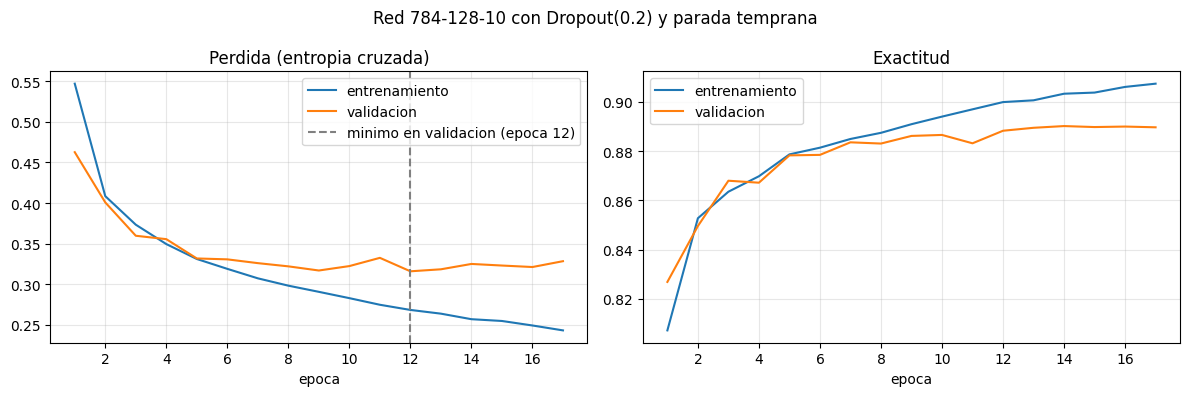

Entrenamiento detenido tras 17 epocas; pesos restaurados de la epoca 12


In [10]:
tf.keras.utils.set_random_seed(2026)
modelo_reg = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax")
], name="mlp_128_dropout")
modelo_reg.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

parada = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
hist_reg = modelo_reg.fit(x_train, y_train, epochs=40, batch_size=32,
                          validation_data=(x_val, y_val), callbacks=[parada], verbose=2)
mejor_reg = curvas(hist_reg, "Red 784-128-10 con Dropout(0.2) y parada temprana")
print(f"Entrenamiento detenido tras {len(hist_reg.history['loss'])} epocas; pesos restaurados de la epoca {mejor_reg}")

## 7. Evaluación sobre el conjunto de prueba

Solo ahora, con los tres modelos definidos, se usa el conjunto de prueba.

In [11]:
print(f"{'Modelo':<34}{'Parametros':>12}{'Perdida':>10}{'Exactitud':>11}")
print("-" * 67)
resultados = {}
for m in (modelo_ref, modelo, modelo_reg):
    perdida_t, exact_t = m.evaluate(x_test, y_test, verbose=0)
    resultados[m.name] = exact_t
    print(f"{m.name:<34}{m.count_params():>12,}{perdida_t:>10.4f}{exact_t:>11.4f}")

Modelo                              Parametros   Perdida  Exactitud
-------------------------------------------------------------------


referencia_sin_capas_ocultas             7,850    0.4564     0.8399


mlp_128                                101,770    0.5375     0.8672


mlp_128_dropout                        101,770    0.3416     0.8828


**`evaluate`** propaga el conjunto de prueba y devuelve la pérdida y las métricas declaradas en `compile`, sin modificar los pesos.

La capa oculta eleva la exactitud del 84.0 % del modelo sin capas ocultas al 86.7 %, y con regularización al 88.3 %, lo que confirma que las no linealidades sirven también en un problema real y no solo en la XOR. La comparación entre las dos redes de 128 neuronas es aún más clara en la pérdida: la red sin regularizar, tras 30 épocas, tiene una pérdida de prueba de 0.54, incluso peor que la del modelo sin capas ocultas (0.46), mientras que la regularizada baja a 0.34. La red sobreentrenada se equivoca con mucha seguridad, asignando probabilidades altas a la clase incorrecta, y eso es precisamente lo que castiga la entropía cruzada.

## 8. Verificación: la propagación hecha a mano

Para comprobar que la red de Keras realiza exactamente las operaciones de la sección 5.4 del capítulo, se extraen sus pesos con `get_weights()` y se repite la propagación con NumPy:

$$Z^{(1)} = W^{(1)T}X + B^{(1)},\quad A^{(1)} = \text{ReLU}(Z^{(1)}),\quad Z^{(2)} = W^{(2)T}A^{(1)} + B^{(2)},\quad A^{(2)} = \text{softmax}(Z^{(2)})$$

En la inferencia *Dropout* no actúa, así que no aparece en las ecuaciones.

In [12]:
W1, B1, W2, B2 = modelo_reg.get_weights()
print("Formas: W1", W1.shape, " B1", B1.shape, " W2", W2.shape, " B2", B2.shape)

X = x_test.reshape(-1, 784)                     # cada fila es un vector X de 784 caracteristicas
Z1 = X @ W1 + B1
A1 = np.maximum(0, Z1)                          # ReLU
Z2 = A1 @ W2 + B2
A2 = np.exp(Z2 - Z2.max(axis=1, keepdims=True)) # softmax numericamente estable
A2 = A2 / A2.sum(axis=1, keepdims=True)

P_keras = modelo_reg.predict(x_test, verbose=0)
print("Diferencia maxima entre probabilidades (NumPy vs Keras):", np.abs(A2 - P_keras).max())
print("Predicciones de clase coincidentes:", np.mean(A2.argmax(1) == P_keras.argmax(1)) * 100, "%")

Formas: W1 (784, 128)  B1 (128,)  W2 (128, 10)  B2 (10,)


Diferencia maxima entre probabilidades (NumPy vs Keras): 1.8775463e-06
Predicciones de clase coincidentes: 100.0 %


Las probabilidades calculadas a mano coinciden con las de Keras con una diferencia máxima del orden de $10^{-6}$, atribuible al redondeo de la precisión simple con la que trabaja TensorFlow, y las 10 000 predicciones de clase son idénticas. TensorFlow no hace nada distinto de lo que describe el capítulo; lo que aporta es el cálculo automático de los gradientes y la eficiencia.

## 9. Análisis de las predicciones

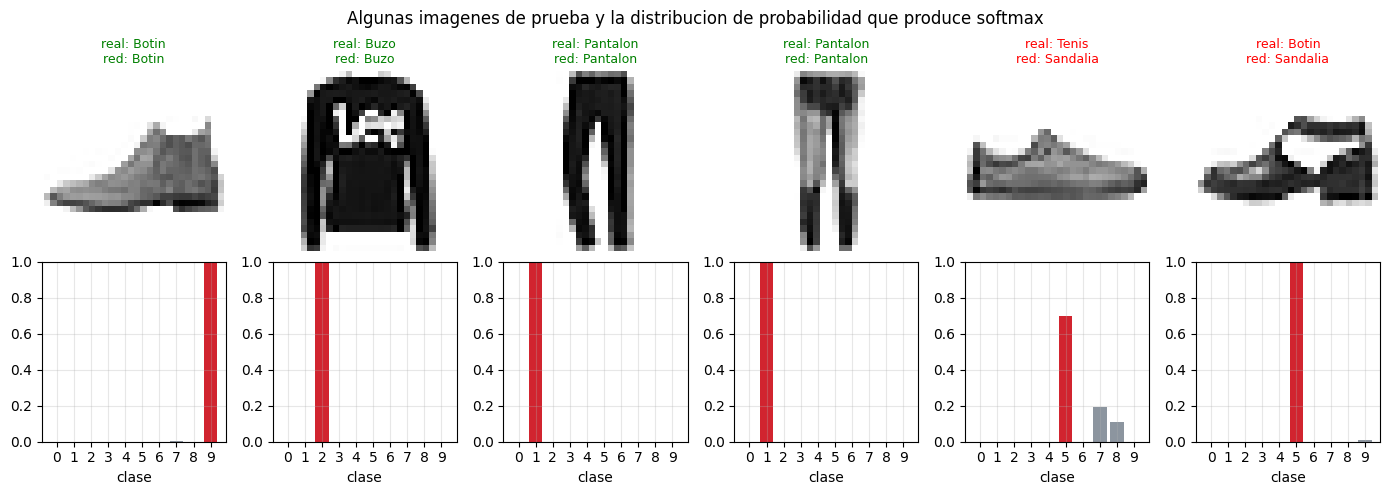

In [13]:
pred = P_keras.argmax(axis=1)

fig, ax = plt.subplots(2, 6, figsize=(14, 5))
idx = [0, 1, 2, 3, 12, 23]
for j, i in enumerate(idx):
    color = "green" if pred[i] == y_test[i] else "red"
    ax[0, j].imshow(x_test[i], cmap="gray_r"); ax[0, j].axis("off")
    ax[0, j].set_title(f"real: {nombres[y_test[i]]}\nred: {nombres[pred[i]]}", fontsize=9, color=color)
    ax[1, j].bar(range(10), P_keras[i], color=["#d1242f" if c == pred[i] else "#8c959f" for c in range(10)])
    ax[1, j].set_ylim(0, 1); ax[1, j].set_xticks(range(10))
    ax[1, j].set_xlabel("clase")
plt.suptitle("Algunas imagenes de prueba y la distribucion de probabilidad que produce softmax")
plt.tight_layout(); plt.show()

**`predict`** devuelve, para cada imagen, el vector de 10 probabilidades de la capa softmax; `argmax` escoge la clase más probable. Las barras permiten ver la confianza de la red: en la mayoría de imágenes una sola clase concentra casi toda la probabilidad, mientras que en los casos dudosos la probabilidad se reparte entre clases parecidas.

### 9.1 Matriz de confusión

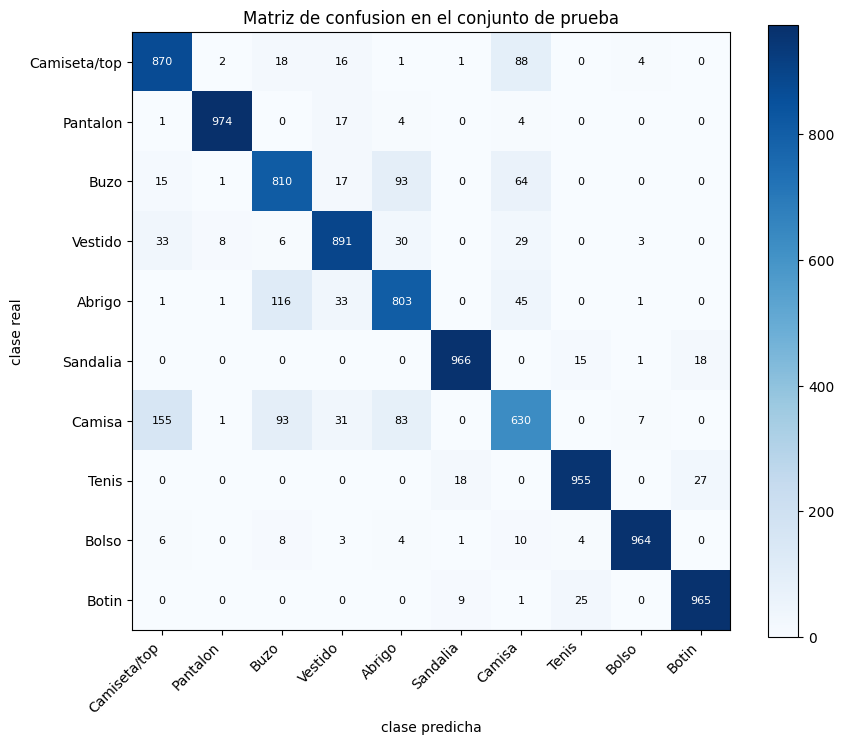

Clase           Exactitud por clase
Camisa                        0.630
Abrigo                        0.803
Buzo                          0.810
Camiseta/top                  0.870
Vestido                       0.891
Tenis                         0.955
Bolso                         0.964
Botin                         0.965
Sandalia                      0.966
Pantalon                      0.974

Confusiones mas frecuentes (real -> predicha):
    155  Camisa -> Camiseta/top
    116  Abrigo -> Buzo
     93  Camisa -> Buzo
     93  Buzo -> Abrigo
     88  Camiseta/top -> Camisa
     83  Camisa -> Abrigo


In [14]:
cm = tf.math.confusion_matrix(y_test, pred, num_classes=10).numpy()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cm, cmap="Blues")
for (r, c), v in np.ndenumerate(cm):
    ax.text(c, r, v, ha="center", va="center", fontsize=8, color="white" if v > 500 else "black")
ax.set_xticks(range(10)); ax.set_xticklabels(nombres, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(nombres)
ax.set_xlabel("clase predicha"); ax.set_ylabel("clase real"); ax.grid(False)
ax.set_title("Matriz de confusion en el conjunto de prueba")
fig.colorbar(im); plt.tight_layout(); plt.show()

print(f"{'Clase':<15}{'Exactitud por clase':>20}")
for c in np.argsort(np.diag(cm)):
    print(f"{nombres[c]:<15}{cm[c, c] / cm[c].sum():>20.3f}")

errores = [(cm[r, c], nombres[r], nombres[c]) for r in range(10) for c in range(10) if r != c]
print("\nConfusiones mas frecuentes (real -> predicha):")
for n, r, c in sorted(errores, reverse=True)[:6]:
    print(f"   {n:>4}  {r} -> {c}")

**`tf.math.confusion_matrix`** cuenta, para cada clase real (fila), cuántas imágenes fueron asignadas a cada clase predicha (columna). La diagonal son los aciertos.

La matriz muestra que el error no está repartido al azar. Pantalones, bolsos, sandalias, tenis y botines se reconocen por encima del 95 %, porque su silueta es muy característica. La clase más difícil, por amplio margen, es **Camisa**, con solo 63 % de aciertos, que se confunde sobre todo con camiseta, buzo y abrigo: las cuatro son prendas superiores con mangas cuya silueta a 28 × 28 píxeles es casi la misma. También hay confusión entre tenis, sandalias y botines, aunque bastante menor.

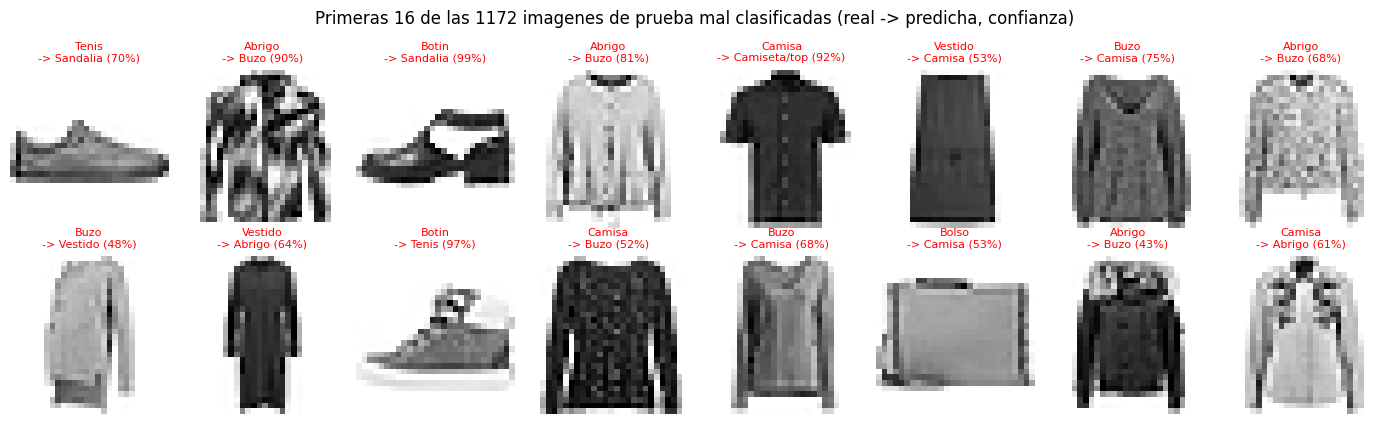

In [15]:
mal = np.where(pred != y_test)[0]
fig, ax = plt.subplots(2, 8, figsize=(14, 4.4))
for a, i in zip(ax.ravel(), mal[:16]):
    a.imshow(x_test[i], cmap="gray_r"); a.axis("off")
    a.set_title(f"{nombres[y_test[i]]}\n-> {nombres[pred[i]]} ({P_keras[i].max():.0%})", fontsize=8, color="red")
plt.suptitle(f"Primeras 16 de las {len(mal)} imagenes de prueba mal clasificadas (real -> predicha, confianza)")
plt.tight_layout(); plt.show()

Al observar los errores se entiende parte de ellos: varias imágenes son ambiguas incluso para una persona, y en algunos casos el rótulo del conjunto de datos es discutible. Esto indica que una parte del error restante no se puede eliminar con una red mayor, porque proviene de la información que hay en la propia imagen.

## 10. Resumen de las funciones utilizadas

| Función o instrucción | Qué hace | Relación con el capítulo |
|---|---|---|
| `tf.keras.datasets.fashion_mnist.load_data()` | descarga y carga el conjunto en arreglos de NumPy | conjunto de entrenamiento $(X^{(i)}, Y^{(i)})$ |
| `x / 255.0` | normaliza los píxeles a $[0,1]$ | escala de las características |
| `tf.keras.Sequential` | red *feedforward* por capas | figura 5.13, propagación |
| `layers.Flatten` | matriz 28×28 → vector de 784 | vector de características $X$ |
| `layers.Dense(n, activation=g)` | $A = g(W^TA_{prev}+B)$ | neurona artificial, sección 5.2.2 |
| `activation="relu"` | $\max(0,z)$ | figura 5.7 |
| `activation="softmax"` | probabilidades que suman 1 | salida de multi-clasificación, $k=10$ |
| `layers.Dropout(p)` | apaga neuronas al azar al entrenar | regularización contra el sobreentrenamiento |
| `model.summary()` | lista capas y número de parámetros | dimensión de $W$ y $B$ por capa |
| `model.compile(optimizer, loss, metrics)` | configura el algoritmo de aprendizaje | sección 5.5 |
| `optimizers.Adam(learning_rate)` | descenso del gradiente con tasa adaptativa | $W \leftarrow W-\eta\,\nabla E$ |
| `SparseCategoricalCrossentropy` | $E=-\ln p_y$ | función de pérdida |
| `model.fit(...)` | ciclo de épocas y lotes con retropropagación | *Backpropagation* |
| `callbacks.EarlyStopping` | detiene al dejar de mejorar la validación | figuras 5.12 y 5.17 |
| `model.evaluate(...)` | pérdida y exactitud sin tocar los pesos | estimación con el conjunto de prueba |
| `model.predict(...)` | probabilidades de salida | $H_w(X)$ |
| `model.get_weights()` | matrices $W$ y vectores $B$ entrenados | verificación manual |
| `tf.math.confusion_matrix` | tabla real × predicho | análisis de errores |

## 11. Conclusiones

In [16]:
print("Exactitud en el conjunto de prueba (10 000 imagenes nunca vistas):")
for k, v in resultados.items():
    print(f"   {k:<34}{v:.2%}")
print(f"\nMejor clase: {nombres[np.argmax(np.diag(cm))]}  ({cm.diagonal().max()/1000:.1%})")
print(f"Peor clase:  {nombres[np.argmin(np.diag(cm))]}  ({cm.diagonal().min()/1000:.1%})")

Exactitud en el conjunto de prueba (10 000 imagenes nunca vistas):
   referencia_sin_capas_ocultas      83.99%
   mlp_128                           86.72%
   mlp_128_dropout                   88.28%

Mejor clase: Pantalon  (97.4%)
Peor clase:  Camisa  (63.0%)


1. **Una red de una sola capa oculta clasifica correctamente el 88.3 % de las prendas** del conjunto de prueba, frente a un 84.0 % de la red sin capas ocultas y un 10 % de un clasificador al azar. Con 128 neuronas ocultas y cerca de cien mil parámetros, el entrenamiento en CPU tarda unos pocos segundos por época.
2. **La capa oculta es la que marca la diferencia.** El modelo de referencia solo puede trazar fronteras lineales en el espacio de 784 píxeles. La capa oculta con ReLU permite combinar rasgos (una manga, una suela, un asa), del mismo modo que en el Ejercicio 1 permitía resolver la XOR.
3. **El sobreentrenamiento aparece pronto y es fácil de reconocer.** Sin regularización, la pérdida de validación toca su mínimo hacia la época 8 y después sube mientras la de entrenamiento sigue bajando, tal como describe la figura 5.17 del capítulo. *Dropout* y la parada temprana con restauración de los mejores pesos resuelven el problema de forma automática y dan un modelo con menor pérdida de prueba.
4. **Keras implementa exactamente las ecuaciones del capítulo.** Al repetir la propagación con los pesos extraídos, las 10 000 predicciones coinciden con las de TensorFlow. La librería no cambia el modelo matemático; automatiza la retropropagación y la hace eficiente.
5. **Los errores tienen una causa identificable.** La mayoría ocurre entre las prendas superiores (camisa, camiseta, buzo y abrigo), cuya silueta es casi igual a 28 × 28 píxeles, y algunos se deben a imágenes ambiguas. Una red densa trata cada píxel como una característica independiente y no aprovecha la estructura espacial de la imagen. El Ejercicio 4 aborda esa limitación con una red convolucional, que en este mismo conjunto llega al 91.1 %, aunque la clase *Camisa* sigue siendo difícil también para ella.